shape: (200, 4)
      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9

missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

summary stats:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000

correlation with Sales:
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

train rows: 160, test rows: 40

Linear Regress

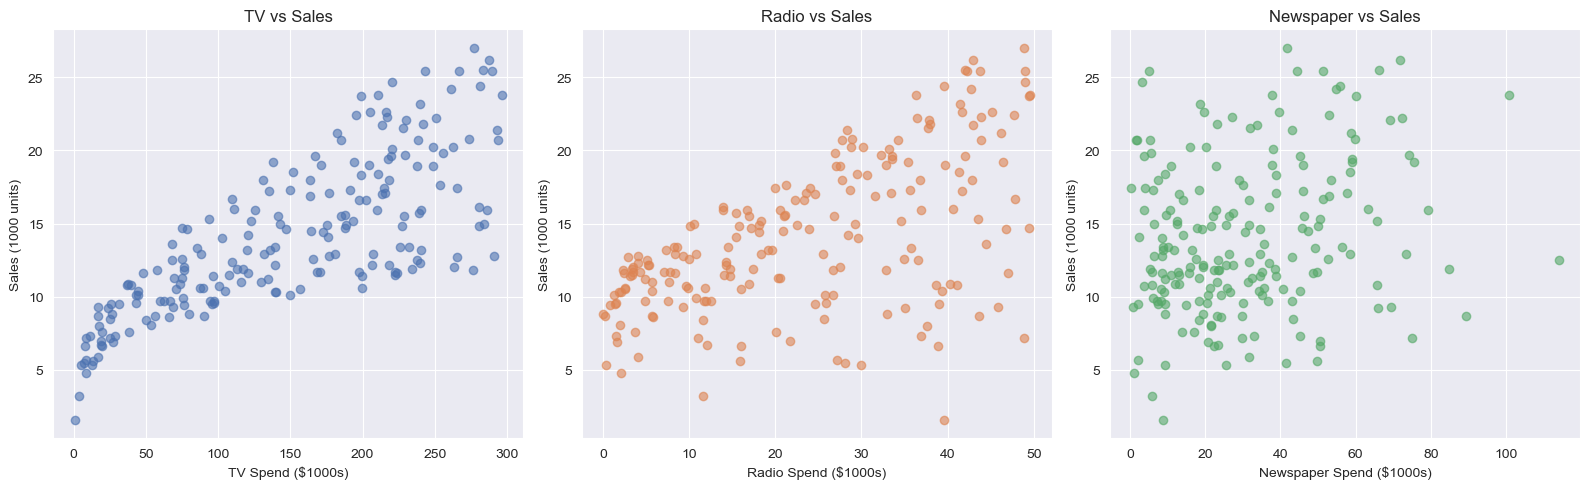

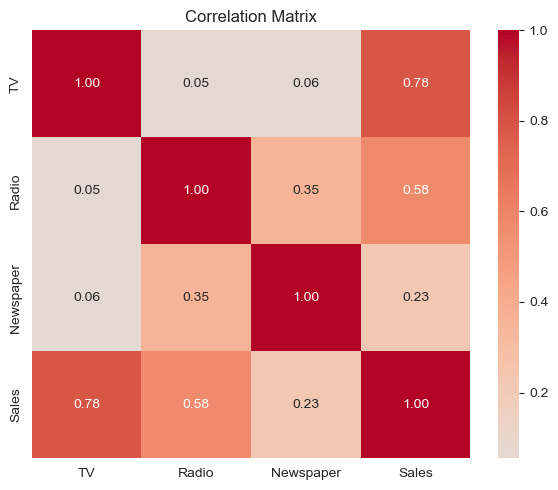

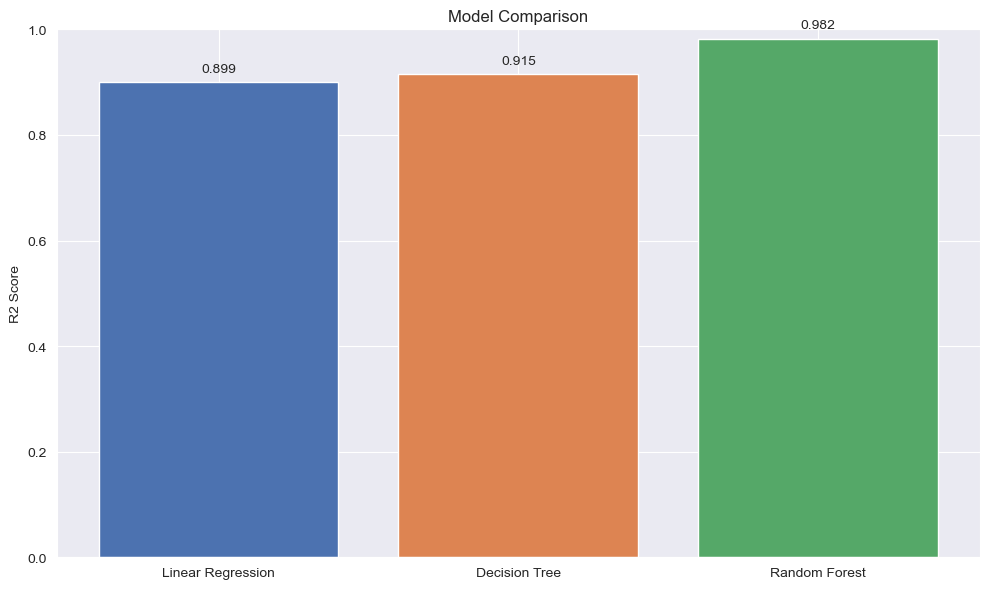

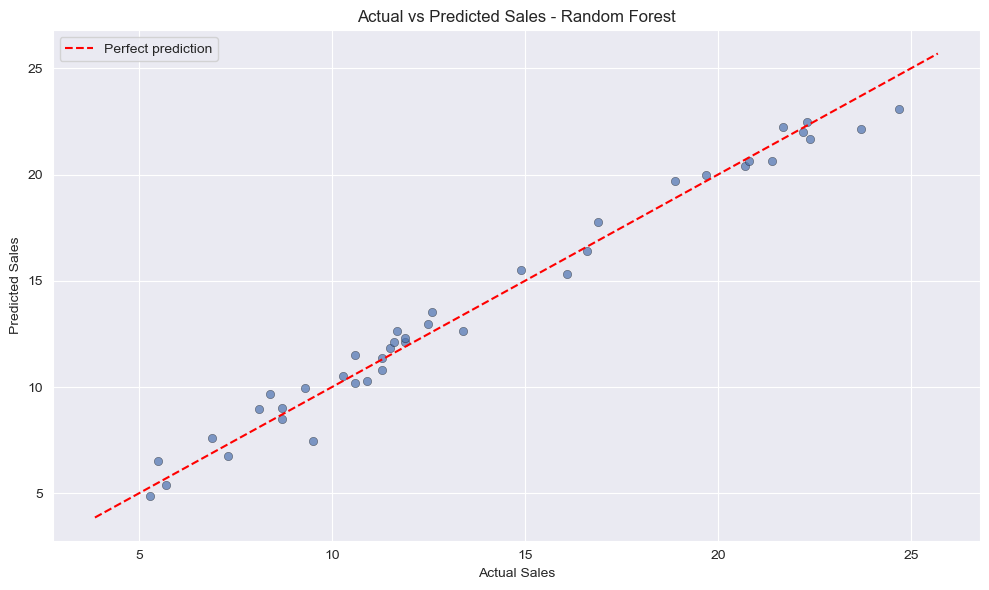

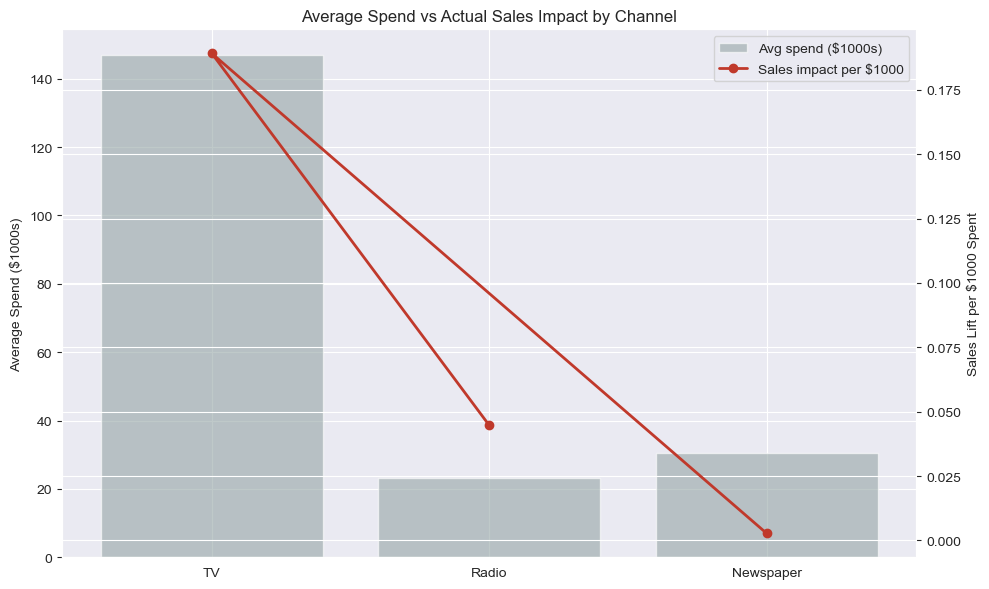

In [2]:
# Sales Prediction from Advertising Spend
# Basic idea: does spending more on TV/Radio/Newspaper ads actually move sales,
# and if so, which channel gives the best bang for the buck?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

# ---- load the data ----
# first column in the csv is just a row index, so drop it on load
df = pd.read_csv("Advertising.csv", index_col=0)

print("shape:", df.shape)
print(df.head())
print("\nmissing values:")
print(df.isnull().sum())  # dataset's clean, no nulls to deal with

print("\nsummary stats:")
print(df.describe())

# spend is in thousands of dollars, sales in thousands of units (standard
# for this dataset) - worth noting since it affects how we read the coefficients later

# ---- how much is spent on each channel, and does it relate to sales? ----

print("\ncorrelation with Sales:")
print(df.corr()["Sales"].sort_values(ascending=False))

# TV and Radio both correlate strongly with sales, Newspaper barely does

# ---- visualize each channel vs sales ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels = ["TV", "Radio", "Newspaper"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
for ax, channel, color in zip(axes, channels, colors):
    ax.scatter(df[channel], df["Sales"], alpha=0.6, color=color)
    ax.set_xlabel(f"{channel} Spend ($1000s)")
    ax.set_ylabel("Sales (1000 units)")
    ax.set_title(f"{channel} vs Sales")
plt.tight_layout()


# correlation heatmap, always useful to eyeball this
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()


# ---- train/test split ----
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\ntrain rows: {len(X_train)}, test rows: {len(X_test)}")


models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results[name] = {"r2": r2, "mae": mae, "rmse": rmse, "preds": preds, "model": model}
    print(f"\n{name}")
    print(f"  R2   : {r2:.4f}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")

best_name = max(results, key=lambda k: results[k]["r2"])
best_model = results[best_name]["model"]
best_preds = results[best_name]["preds"]
print(f"\nbest model: {best_name} (R2 = {results[best_name]['r2']:.4f})")


lin_model = results["Linear Regression"]["model"]
coefs = pd.Series(lin_model.coef_, index=X.columns).sort_values(ascending=False)
print("\nlinear regression coefficients (extra sales per extra $1000 spent):")
print(coefs)
print(f"intercept (baseline sales with zero ad spend): {lin_model.intercept_:.2f}")

# quick sanity interpretation
print("\nroughly speaking:")
for channel in coefs.index:
    print(f"  every extra $1000 on {channel} -> about {coefs[channel]*1000:.0f} extra units sold")

# ---- feature importance from random forest, cross-check against the coefficients ----
if "Random Forest" in results:
    rf = results["Random Forest"]["model"]
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nrandom forest feature importance:")
    print(importances)


# 1. model comparison bar chart
fig, ax = plt.subplots()
names = list(results.keys())
r2_scores = [results[n]["r2"] for n in names]
bars = ax.bar(names, r2_scores, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("R2 Score")
ax.set_title("Model Comparison")
ax.set_ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.3f}", ha="center")
plt.tight_layout()

# 2. actual vs predicted for best model
fig, ax = plt.subplots()
ax.scatter(y_test, best_preds, alpha=0.7, color="#4C72B0", edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), best_preds.min()) - 1, max(y_test.max(), best_preds.max()) + 1]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.set_title(f"Actual vs Predicted Sales - {best_name}")
ax.legend()
plt.tight_layout()


# 3. ad spend budget allocation chart - avg spend per channel vs its "effectiveness"
fig, ax = plt.subplots()
avg_spend = df[["TV", "Radio", "Newspaper"]].mean()
ax2 = ax.twinx()
ax.bar(avg_spend.index, avg_spend.values, color="#95a5a6", alpha=0.6, label="Avg spend ($1000s)")
ax2.plot(coefs.index, coefs.reindex(avg_spend.index).values, color="#c0392b", marker="o", linewidth=2, label="Sales impact per $1000")
ax.set_ylabel("Average Spend ($1000s)")
ax2.set_ylabel("Sales Lift per $1000 Spent")
ax.set_title("Average Spend vs Actual Sales Impact by Channel")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()


